In [1]:
import numpy as np


def thomas_solve(a, b, c, d):
    """Solve tridiagonal system A x = d using the Thomas algorithm.

    A has subdiagonal a, diagonal b, superdiagonal c.
    a, b, c, d are 1D numpy arrays (a[0] unused, c[-1] unused).
    Returns x (1D array).
    """
    n = len(d)
    ac = a.copy().astype(float)
    bc = b.copy().astype(float)
    cc = c.copy().astype(float)
    dc = d.copy().astype(float)

    # Forward elimination
    for i in range(1, n):
        m = ac[i] / bc[i - 1]
        bc[i] = bc[i] - m * cc[i - 1]
        dc[i] = dc[i] - m * dc[i - 1]

    # Back substitution
    x = np.zeros(n, dtype=float)
    x[-1] = dc[-1] / bc[-1]
    for i in range(n - 2, -1, -1):
        x[i] = (dc[i] - cc[i] * x[i + 1]) / bc[i]

    return x


def adi_diffusion(
    u0, D, Lx, Ly, Nx, Ny, dt, T, bc_func=None, source_func=None, save_steps=None
):
    """
    ADI (Peaceman-Rachford) solver for u_t = D (u_xx + u_yy) + s.

    Parameters
    ----------
    u0 : callable or 2D array
        Initial condition. If callable, called as u0(X, Y) where X,Y are meshgrid arrays (Ny,Nx).
    D : float
        Diffusion coefficient (scalar).
    Lx, Ly : floats
        Domain size in x and y.
    Nx, Ny : ints
        Number of cells in x and y (uniform grid, cell-centred).
    dt : float
        Time step.
    T : float
        Final time.
    bc_func : callable or None
        Boundary condition function. If None, zero Dirichlet is used.
        Should have signature bc_func(side, coord, t) where side in {'left','right','bottom','top'}
        and coord is the coordinate along the boundary (y for left/right, x for bottom/top).
    source_func : callable or None
        Source term function s(x,y,t). If None, no source.
    save_steps : list of floats or None
        Times at which to save snapshots.

    Returns
    -------
    x, y : 1D arrays
        Cell-center coordinates in x and y.
    snapshots : dict
        Mapping time -> 2D array (Ny,Nx) for saved times.
    u : 2D array
        Final solution at time T.
    """
    # grid (cell centers)
    dx = Lx / Nx
    dy = Ly / Ny
    x = (np.arange(Nx) + 0.5) * dx
    y = (np.arange(Ny) + 0.5) * dy

    X, Y = np.meshgrid(x, y)

    # initial condition
    if callable(u0):
        u = u0(X, Y)
    else:
        u = np.array(u0, dtype=float)

    nt = int(np.ceil(T / dt))

    # ADI factors
    r_x = D * dt / (2.0 * dx * dx)
    r_y = D * dt / (2.0 * dy * dy)

    nx = Nx
    ny = Ny

    # tridiagonal coefficients for constant-coefficient problems
    ax = np.zeros(nx)
    bx = np.zeros(nx)
    cx = np.zeros(nx)
    ay = np.zeros(ny)
    by = np.zeros(ny)
    cy = np.zeros(ny)

    bx[:] = 1.0 + 2.0 * r_x
    ax[1:] = -r_x
    cx[:-1] = -r_x

    by[:] = 1.0 + 2.0 * r_y
    ay[1:] = -r_y
    cy[:-1] = -r_y

    if bc_func is None:

        def bc_func(side, coord, t):
            return 0.0

    snapshots = {}
    current_time = 0.0
    if save_steps is None:
        save_steps = []
    save_times = set(save_steps)

    # time-stepping
    for n in range(nt):
        t = current_time

        # First half-step: implicit in x, explicit in y (using u^n)
        u_star = np.zeros_like(u)
        for j in range(ny):
            RHS = np.zeros(nx, dtype=float)
            for i in range(nx):
                uij = u[j, i]

                # discrete second derivative in y at time t (explicit)
                if j == 0:
                    u_jm1 = bc_func("bottom", x[i], t)
                else:
                    u_jm1 = u[j - 1, i]
                if j == ny - 1:
                    u_jp1 = bc_func("top", x[i], t)
                else:
                    u_jp1 = u[j + 1, i]

                lap_y = (u_jm1 - 2.0 * uij + u_jp1) / (dy * dy)
                s_val = 0.0 if source_func is None else source_func(x[i], y[j], t)

                # RHS for the x-implicit solve
                RHS[i] = uij + 0.5 * dt * (D * lap_y + s_val)

            # adjust RHS for Dirichlet boundary values (ghosts moved to RHS)
            gL = bc_func("left", y[j], t)
            gR = bc_func("right", y[j], t)
            RHS[0] += r_x * gL
            RHS[-1] += r_x * gR

            # solve tridiagonal for this row
            u_row = thomas_solve(ax, bx, cx, RHS)
            u_star[j, :] = u_row

        # Second half-step: implicit in y, explicit in x (using u_star)
        u_new = np.zeros_like(u)
        for i in range(nx):
            RHS = np.zeros(ny, dtype=float)
            for j in range(ny):
                uij_star = u_star[j, i]

                # discrete second derivative in x at time t+dt/2 (explicit)
                if i == 0:
                    u_im1 = bc_func("left", y[j], t + 0.5 * dt)
                else:
                    u_im1 = u_star[j, i - 1]
                if i == nx - 1:
                    u_ip1 = bc_func("right", y[j], t + 0.5 * dt)
                else:
                    u_ip1 = u_star[j, i + 1]

                lap_x = (u_im1 - 2.0 * uij_star + u_ip1) / (dx * dx)
                s_val = (
                    0.0
                    if source_func is None
                    else source_func(x[i], y[j], t + 0.5 * dt)
                )

                RHS[j] = uij_star + 0.5 * dt * (D * lap_x + s_val)

            # adjust RHS for Dirichlet at bottom/top
            gB = bc_func("bottom", x[i], t + 0.5 * dt)
            gT = bc_func("top", x[i], t + 0.5 * dt)
            RHS[0] += r_y * gB
            RHS[-1] += r_y * gT

            # solve tridiagonal for this column
            u_col = thomas_solve(ay, by, cy, RHS)
            for j in range(ny):
                u_new[j, i] = u_col[j]

        current_time += dt
        u = u_new

        # save snapshots
        if (
            np.isclose(current_time, np.array(save_steps)).any()
            or current_time in save_times
        ):
            snapshots[round(current_time, 10)] = u.copy()

    return x, y, snapshots, u

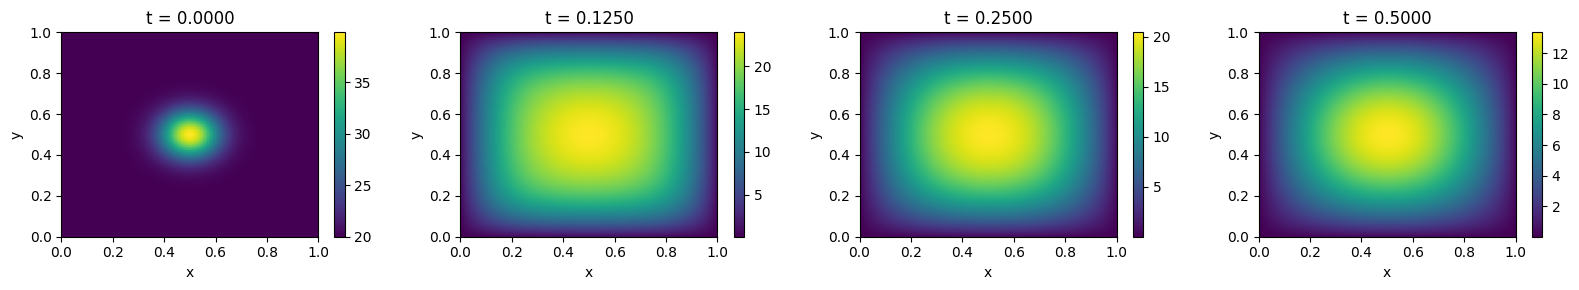

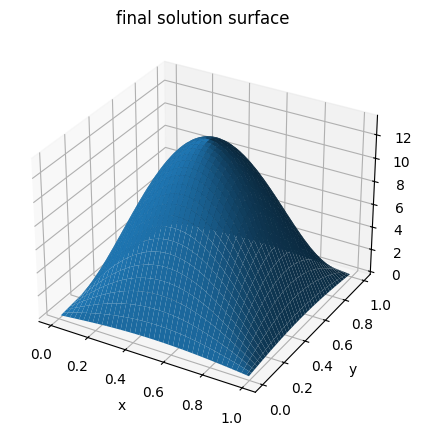

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def gaussian_ic(X, Y, x0=0.5, y0=0.5, sigma=0.08):
    return 20 * np.exp(-((X - x0) ** 2 + (Y - y0) ** 2) / (2.0 * sigma**2)) + 20.0


# domain and solver parameters
Lx = 1.0
Ly = 1.0
Nx = 80
Ny = 80
D = 0.1
dt = 5e-4
T = 0.5
save_times = [0.0, T * 0.25, T * 0.5, T]

x, y, snaps, u_final = adi_diffusion(
    gaussian_ic,
    D,
    Lx,
    Ly,
    Nx,
    Ny,
    dt,
    T,
    bc_func=None,
    source_func=None,
    save_steps=save_times,
)

# plot snapshots
fig, axes = plt.subplots(1, len(save_times), figsize=(4 * len(save_times), 3))
for ax, t in zip(axes, save_times):
    key = round(t, 10)
    if key == 0.0:
        u = gaussian_ic(*np.meshgrid(x, y))
    else:
        u = snaps.get(round(t, 10), None)
        if u is None:
            ks = sorted(list(snaps.keys()))
            u = snaps[ks[-1]]
    im = ax.imshow(u, origin="lower", extent=[0, Lx, 0, Ly], aspect="auto")
    ax.set_title(f"t = {t:.4f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# final 3D surface
Xc, Yc = np.meshgrid(x, y)
fig2 = plt.figure(figsize=(6, 5))
ax3 = fig2.add_subplot(111, projection="3d")
ax3.plot_surface(Xc, Yc, u_final, linewidth=0, antialiased=True)
ax3.set_title("final solution surface")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("u")
plt.show()

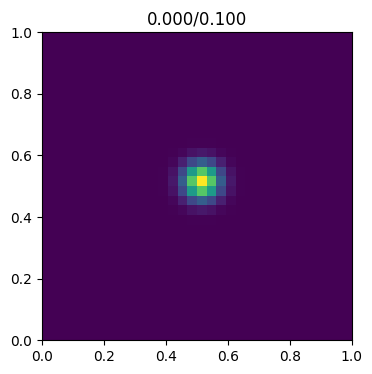

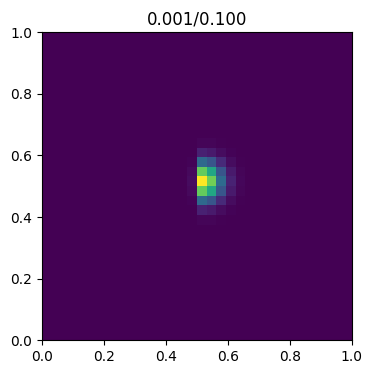

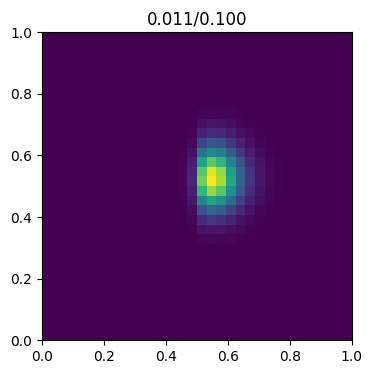

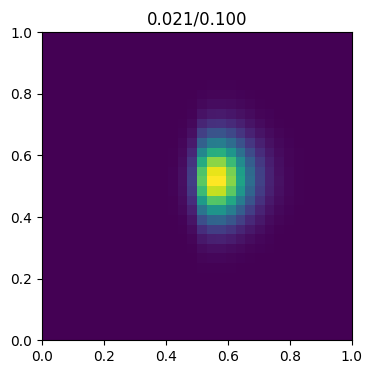

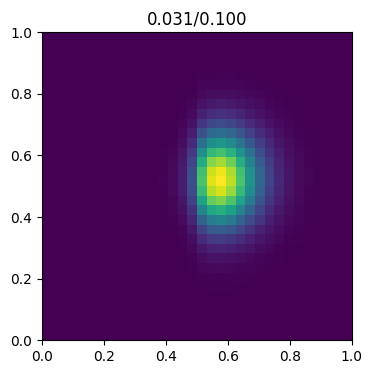

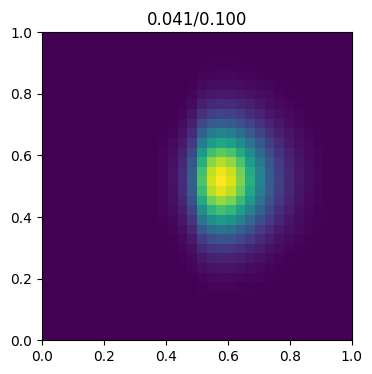

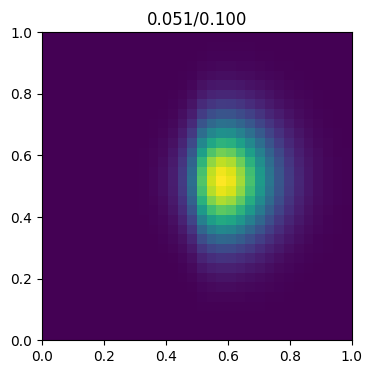

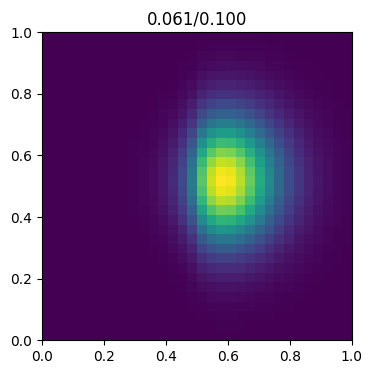

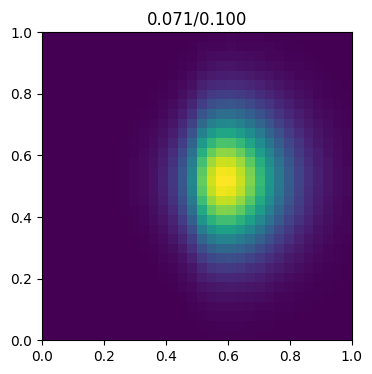

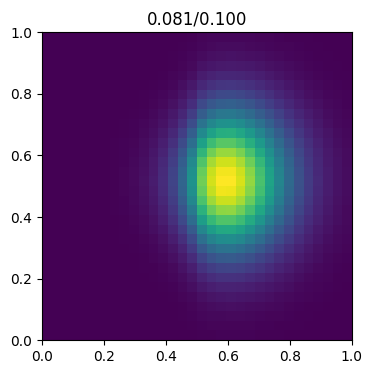

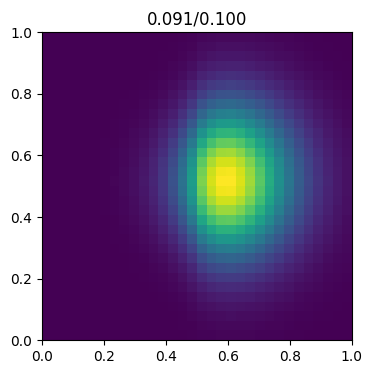

max u: 0.058211765552525725 min u: 7.645445432741045e-05


In [31]:
import numpy as np


def thomas_tridiag(a, b, c, d):
    """
    Solve tridiagonal system with vectors a (sub, length n), b (diag), c (super) and rhs d.
    a[0] is unused (can be 0). Returns solution x.
    Operates on 1D numpy arrays.
    """
    n = b.size
    # forward eliminate
    for i in range(1, n):
        m = a[i] / b[i - 1]
        b[i] -= m * c[i - 1]
        d[i] -= m * d[i - 1]
    d[-1] = d[-1] / b[-1]
    for i in range(n - 2, -1, -1):
        d[i] = (d[i] - c[i] * d[i + 1]) / b[i]


def harmonic_mean(a, b):
    """Harmonic mean of a and b, handling zeros robustly."""
    eps = 1e-16
    a = np.asarray(a)
    b = np.asarray(b)
    denom = 1.0 / (a + eps) + 1.0 / (b + eps)
    return 2.0 / denom


def adi_diffusion_3d_varD(u0_func, D_func, Lx, Ly, Lz, Nx, Ny, Nz, dt, T):
    """
    3D ADI solver with spatially varying D.
    Parameters:
        u0_func(x,y,z) -> initial field
        D_func(x,y,z) -> diffusion coefficient (>=0)
        Lx,Ly,Lz -> domain sizes
        Nx,Ny,Nz -> number of cells (uniform)
        dt, T -> timestep and final time
        bc_type -> 'dirichlet' or 'neumann' (applies same type on all faces)
        bc_value -> scalar (Dirichlet value or Neumann flux value; for Neumann we assume zero flux if 0.0)
        source_func(x,y,z,t) -> optional source term; if None, zero source
        save_times -> list of times to store snapshots (optional)

    Returns:
        x,y,z arrays (cell centers), snapshots dict time->u array, final u (Nz,Ny,Nx)
    """
    dx = Lx / Nx
    dy = Ly / Ny
    dz = Lz / Nz

    # initial condition
    u = np.zeros((Nz, Ny, Nx), dtype=float)
    u_new = np.zeros((Nz, Ny, Nx), dtype=float)
    for k in range(Nz):
        for j in range(Ny):
            for i in range(Nx):
                x = dx * i
                y = dy * j
                z = dz * k
                u[k, j, i] = u0_func(x, y, z)

    # precompute D at cell centers
    Dcc = np.zeros_like(u)
    for k in range(Nz):
        for j in range(Ny):
            for i in range(Nx):
                x = dx * i
                y = dy * j
                z = dz * k
                Dcc[k, j, i] = D_func(x, y, z)

    nt = int(np.ceil(T / dt))
    rfac_x = dt / (2.0 * dx * dx)
    rfac_y = dt / (2.0 * dy * dy)
    rfac_z = dt / (2.0 * dz * dz)

    tcur = 0.0

    fg, ax = plt.subplots(figsize=(4, 4))
    ax.axis("equal")
    im = ax.imshow(u[:, :, 0], origin="lower", extent=[0, Lx, 0, Ly], aspect="auto")
    ax.set_title(f"{tcur:.3f}/{T:.3f}")
    plt.show()

    ln = max(Nx, max(Ny, Nz))
    a = np.zeros(ln)  # subdiagonal (a[0] unused)
    b = np.zeros(ln)
    c = np.zeros(ln)  # superdiagonal (c[-1] unused)
    RHS = np.zeros(ln)

    # Time loop
    for step in range(nt):
        t = tcur
        # ---- STEP 1: X-implicit, explicit in y,z. Solve for u_star (k,j) lines in x ----
        # For each fixed (k,j) solve tridiagonal in i
        for k in range(Nz):
            for j in range(Ny):
                # build tridiagonal coefficients a,b,c and RHS for i=0..Nx-1
                for i in range(Nx):
                    u_ijk = u[k, j, i]
                    # y-neighbors
                    if j == 0:
                        u_jm = u_ijk
                    else:
                        u_jm = u[k, j - 1, i]
                    if j == Ny - 1:
                        u_jp = u_ijk
                    else:
                        u_jp = u[k, j + 1, i]
                    lap_y = rfac_y * (u_jm - 2.0 * u_ijk + u_jp)
                    # z-neighbors
                    if k == 0:
                        u_km = u_ijk
                    else:
                        u_km = u[k - 1, j, i]
                    if k == Nz - 1:
                        u_kp = u_ijk
                    else:
                        u_kp = u[k + 1, j, i]
                    lap_z = rfac_z * (u_km - 2.0 * u_ijk + u_kp)

                    s = 0.0
                    RHS[i] = u_ijk + Dcc[k, j, i] * (lap_y + lap_z) + 0.5 * dt * s

                    # left face D_{i-1/2}
                    if i == 0:
                        D_imh = Dcc[k, j, 0]
                    else:
                        D_imh = Dcc[k, j, i - 1]
                    if i < Nx - 1:
                        D_iph = Dcc[k, j, i]
                    else:
                        D_iph = Dcc[k, j, -1]
                    ai = rfac_x * D_imh
                    ci = rfac_x * D_iph
                    a[i] = -ai
                    c[i] = -ci
                    b[i] = 1.0 + ai + ci

                # solve tridiagonal
                thomas_tridiag(a, b, c, RHS)
                u_new[k, j, :] = RHS[0:Nx]

        # ---- STEP 2: Y-implicit, explicit in x,z. Solve for u_dblstar along j ----
        for k in range(Nz):
            for i in range(Nx):
                for j in range(Ny):
                    u_ijk = u_new[k, j, i]
                    # x-neighbors explicit
                    if i == 0:
                        u_im = u_ijk
                    else:
                        u_im = u_new[k, j, i - 1]
                    if i == Nx - 1:
                        u_ip = u_ijk
                    else:
                        u_ip = u_new[k, j, i + 1]
                    lap_x = rfac_x * (u_im - 2.0 * u_ijk + u_ip)
                    # z-neighbors explicit
                    if k == 0:
                        u_km = u_ijk
                    else:
                        u_km = u_new[k - 1, j, i]
                    if k == Nz - 1:
                        u_kp = u_ijk
                    else:
                        u_kp = u_new[k + 1, j, i]
                    lap_z = rfac_z * (u_km - 2.0 * u_ijk + u_kp)
                    s = 0.0
                    RHS[j] = u_ijk + Dcc[k, j, i] * (lap_x + lap_z) + 0.5 * dt * s

                    if j == 0:
                        D_jmh = Dcc[k, j, i]
                    else:
                        D_jmh = Dcc[k, j - 1, i]
                    if j < Ny - 1:
                        D_jph = Dcc[k, j, i]
                    else:
                        D_jph = Dcc[k, j, i]
                    aj = rfac_y * D_jmh
                    cj = rfac_y * D_jph
                    a[j] = -aj
                    c[j] = -cj
                    b[j] = 1.0 + aj + cj

                thomas_tridiag(a, b, c, RHS)
                u[k, :, i] = RHS[0:Ny]

        # ---- STEP 3: Z-implicit, explicit in x,y. Solve for u^{n+1} along k ----
        u_new = np.zeros_like(u)
        for j in range(Ny):
            for i in range(Nx):
                for k in range(Nz):
                    u_ijk = u[k, j, i]
                    # x neighbors explicit
                    if i == 0:
                        u_im = u_ijk
                    else:
                        u_im = u[k, j, i - 1]
                    if i == Nx - 1:
                        u_ip = u_ijk
                    else:
                        u_ip = u[k, j, i + 1]
                    lap_x = (u_im - 2.0 * u_ijk + u_ip) * rfac_x
                    # y neighbors explicit
                    if j == 0:
                        u_jm = u_ijk
                    else:
                        u_jm = u[k, j - 1, i]
                    if j == Ny - 1:
                        u_jp = u_ijk
                    else:
                        u_jp = u[k, j + 1, i]
                    lap_y = (u_jm - 2.0 * u_ijk + u_jp) * rfac_y
                    s = 0.0
                    RHS[k] = u_ijk + Dcc[k, j, i] * (lap_x + lap_y) + 0.5 * rfac_y * s

                    if k == 0:
                        D_kmh = Dcc[k, j, i]
                    else:
                        D_kmh = Dcc[k - 1, j, i]
                    if k < Nz - 1:
                        D_kph = Dcc[k, j, i]
                    else:
                        D_kph = Dcc[k, j, i]
                    aik = rfac_z * D_kmh
                    cik = rfac_z * D_kph
                    a[k] = -aik
                    c[k] = -cik
                    b[k] = 1.0 + aik + cik

                thomas_tridiag(a, b, c, RHS)
                u_new[:, j, i] = RHS[0:Nz]

        tcur += dt
        u = u_new
        if step % 10 == 0:
            fg, ax = plt.subplots(figsize=(4, 4))
            ax.axis("equal")
            im = ax.imshow(
                u[:, :, 0], origin="lower", extent=[0, Lx, 0, Ly], aspect="auto"
            )
            ax.set_title(f"{tcur:.3f}/{T:.3f}")
            plt.show()


# ---------------- Example usage ----------------
if __name__ == "__main__":
    # domain
    Lx = Ly = Lz = 1.0
    Nx = Ny = Nz = 32  # keep moderate for example
    dt = 1e-3
    T = 0.1

    # initial condition: gaussian centered at 0.5,0.5,0.5
    def u0(x, y, z):
        x0, y0, z0 = 0.5, 0.5, 0.5
        sig = 0.04
        return np.exp(
            -((x - x0) ** 2 + (y - y0) ** 2 + (z - z0) ** 2) / (2 * sig * sig)
        )

    def Dfunc(x, y, z):
        return 0.05 if (x < 0.5 and y < 0.5) else 0.1

    # zero source
    source = None

    # Neumann BC (zero flux) implemented by mirroring interior value; pass bc_type='neumann'
    adi_diffusion_3d_varD(u0, Dfunc, Lx, Ly, Lz, Nx, Ny, Nz, dt, T)

    print("max u:", np.max(u_final), "min u:", np.min(u_final))

In [32]:
out - xy - (50.000000).csv

NameError: name 'out' is not defined

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
%ls build

"build": No such file or directory (os error 2)


0.0 1.63016e-102 1.17691e-34
100.0 4.52159e-20 6.11187e-08
200.0 7.59836e-13 8.33494e-06
300.0 2.1558e-10 3.75634e-05
400.0 3.00701e-09 6.88788e-05
500.0 1.24404e-08 8.93226e-05
600.0 2.83673e-08 9.86207e-05
700.0 4.65605e-08 0.000100173
800.0 6.27878e-08 9.71335e-05
900.0 7.47734e-08 9.16612e-05


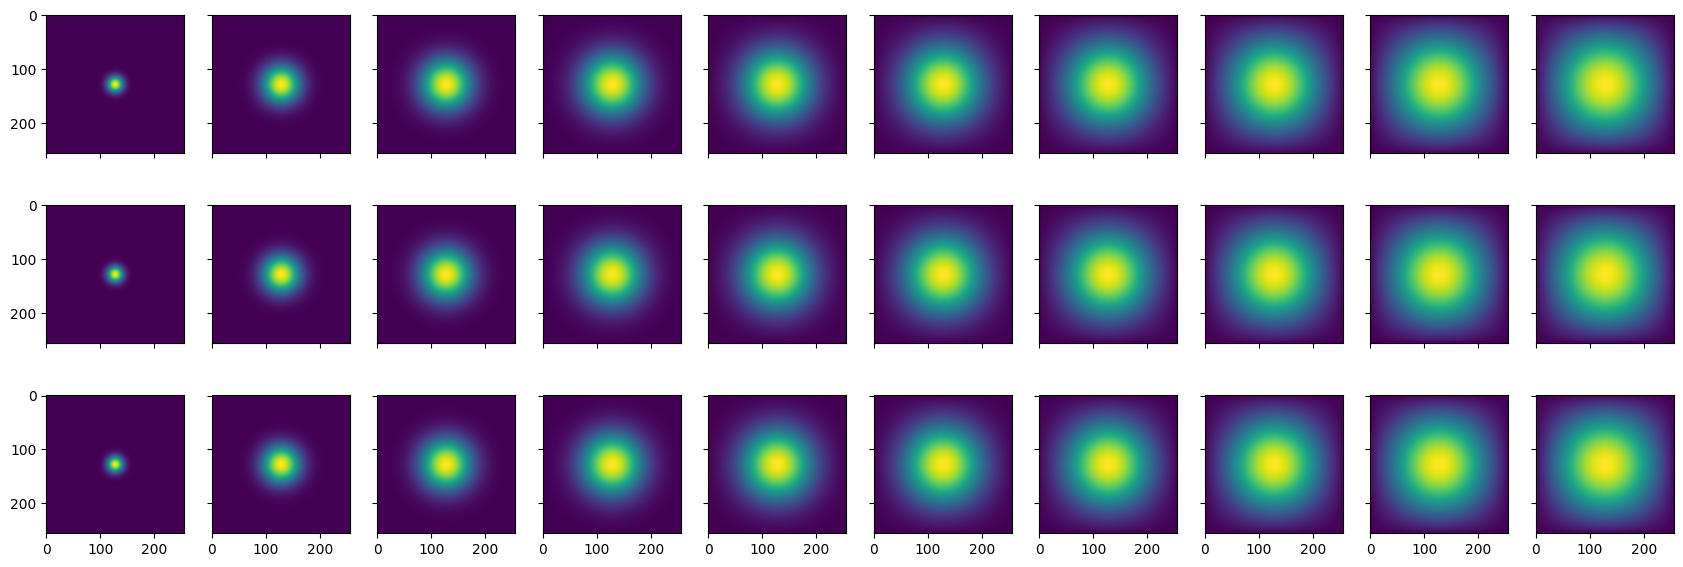

In [14]:
fg, axs = plt.subplots(3, 10, sharex=True, sharey=True, figsize=(21, 7))
for ix, t in enumerate(np.arange(0, 1000, 100.0)):
    try:
        im = np.loadtxt(f"../build/out-xy-{float(t):.6f}.csv", delimiter=",")
        print(t, im.min(), im.max())
        axs[0, ix].imshow(im)
    except Exception as e:
        print(f"xy {float(t):.6f}: {e}")
        pass
    try:
        im = np.loadtxt(f"../build/out-xz-{float(t):.6f}.csv", delimiter=",")
        axs[1, ix].imshow(im)
    except:
        pass
    try:
        im = np.loadtxt(f"../build/out-yz-{float(t):.6f}.csv", delimiter=",")
        axs[2, ix].imshow(im)
    except:
        pass

In [1]:
import arbor as A

In [8]:
mrf = A.load_asc("../cell1.asc")
cell = A.cable_cell(mrf.morphology, A.decor(), A.label_dict())
cell.cv

Docstring:
discretization(*args, **kwargs)
Overloaded function.

1. discretization(self: arbor._arbor.cable_cell) -> Optional[arbor._arbor.cv_policy]

The cv_policy used to discretise the cell into compartments for simulation

2. discretization(self: arbor._arbor.cable_cell, policy: arbor._arbor.cv_policy) -> None

A cv_policy used to discretise the cell into compartments for simulation

3. discretization(self: arbor._arbor.cable_cell, policy: str) -> None

An s-expression string representing a cv_policy used to discretise the cell into compartments for simulation
Type:      method

In [14]:
cvp = A.cell_cv_data(cell)

TypeError: arbor._arbor.cell_cv_data: No constructor defined!

In [13]:
cell.cables("(all)")

[(cable 0 0 1),
 (cable 1 0 1),
 (cable 2 0 1),
 (cable 3 0 1),
 (cable 4 0 1),
 (cable 5 0 1),
 (cable 6 0 1),
 (cable 7 0 1),
 (cable 8 0 1),
 (cable 9 0 1),
 (cable 10 0 1),
 (cable 11 0 1),
 (cable 12 0 1),
 (cable 13 0 1),
 (cable 14 0 1),
 (cable 15 0 1),
 (cable 16 0 1),
 (cable 17 0 1),
 (cable 18 0 1),
 (cable 19 0 1),
 (cable 20 0 1),
 (cable 21 0 1),
 (cable 22 0 1),
 (cable 23 0 1),
 (cable 24 0 1),
 (cable 25 0 1),
 (cable 26 0 1),
 (cable 27 0 1),
 (cable 28 0 1),
 (cable 29 0 1),
 (cable 30 0 1),
 (cable 31 0 1),
 (cable 32 0 1),
 (cable 33 0 1),
 (cable 34 0 1),
 (cable 35 0 1),
 (cable 36 0 1),
 (cable 37 0 1),
 (cable 38 0 1),
 (cable 39 0 1),
 (cable 40 0 1),
 (cable 41 0 1),
 (cable 42 0 1),
 (cable 43 0 1),
 (cable 44 0 1),
 (cable 45 0 1),
 (cable 46 0 1),
 (cable 47 0 1),
 (cable 48 0 1),
 (cable 49 0 1),
 (cable 50 0 1),
 (cable 51 0 1),
 (cable 52 0 1),
 (cable 53 0 1),
 (cable 54 0 1),
 (cable 55 0 1),
 (cable 56 0 1),
 (cable 57 0 1),
 (cable 58 0 1),
 (cable

In [8]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def gaussian(x, y, x0, t):
    # Green's function for the diffusion equation
    dx = x - x0[0]
    dy = y - x0[1]
    return np.exp(-(dx**2 + dy**2) / (4 * t)) / (4 * np.pi * t) + 20

In [13]:
def construct_matrices(n, alpha):
    # This is the matrix for the explicit update on the RHS
    AR = (
        np.diag((1 - alpha) * np.ones(n))
        + np.diag(alpha / 2 * np.ones(n - 1), k=1)
        + np.diag(alpha / 2 * np.ones(n - 1), k=-1)
    )

    # and for the implicit update on the LHS
    b = 1 + alpha * np.ones(n)
    a = -alpha / 2 * np.ones(n)
    a[0] = 0
    c = -alpha / 2 * np.ones(n)
    c[-1] = 0
    AL = np.row_stack((a, b, c))

    return AL, AR

Using matplotlib backend: inline


/var/folders/dv/xz6pnrys46vft3nm92fd_m9m0000gn/T/ipykernel_80700/1015342418.py:11: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  AL = np.row_stack((a,b,c))


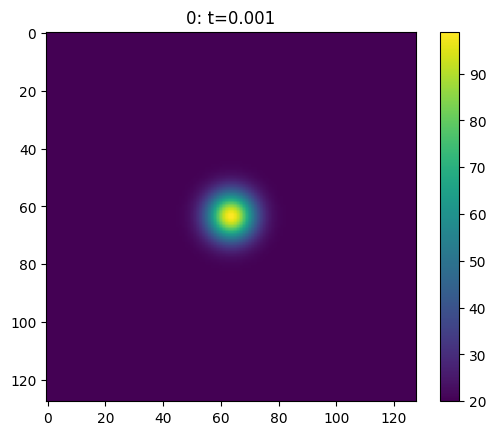

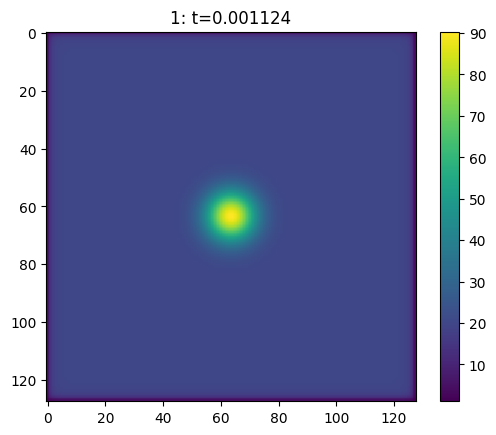

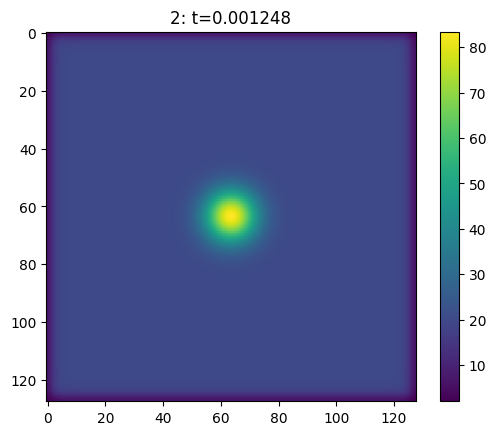

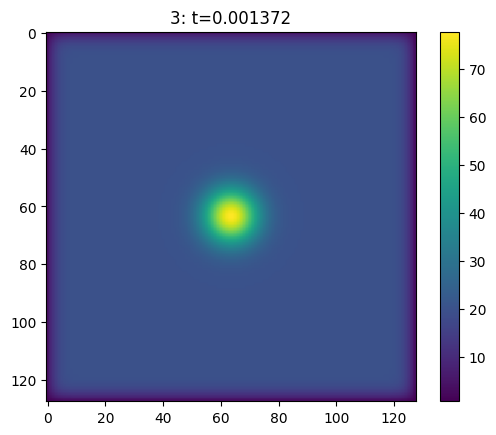

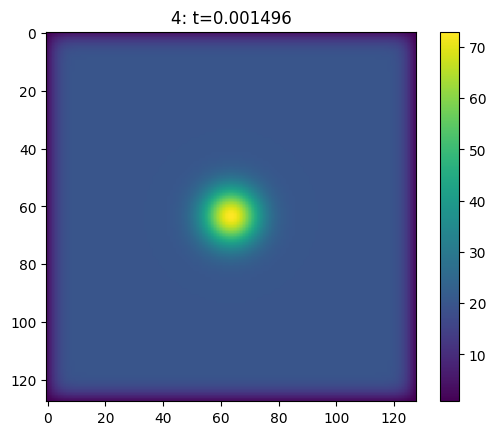

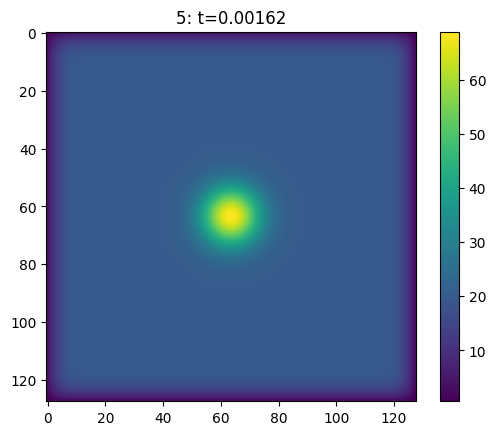

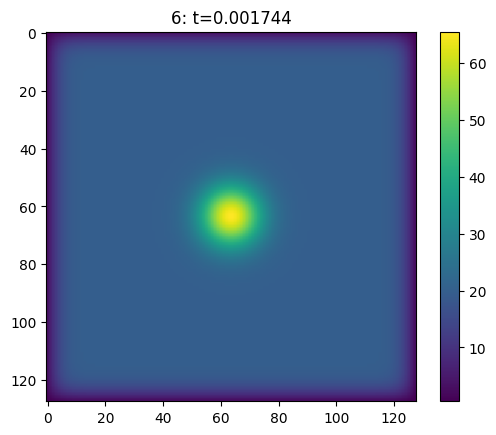

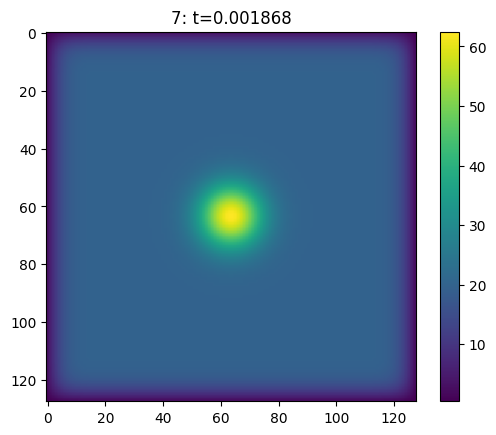

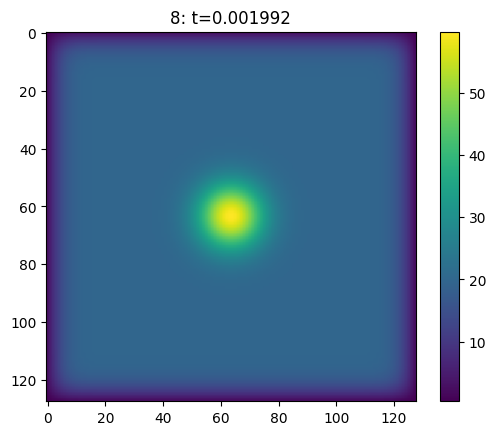

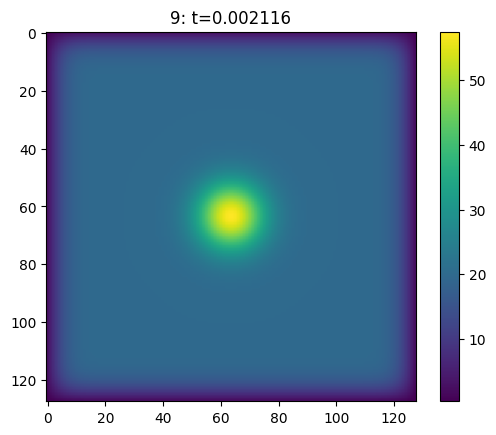

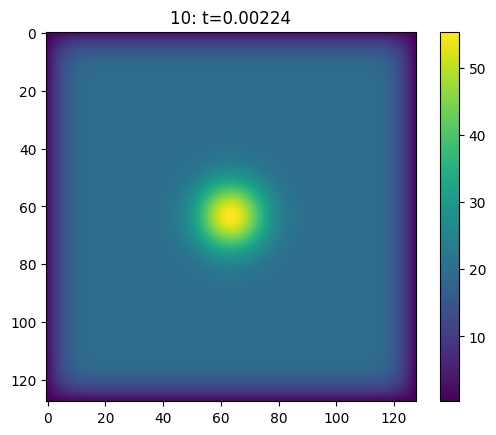

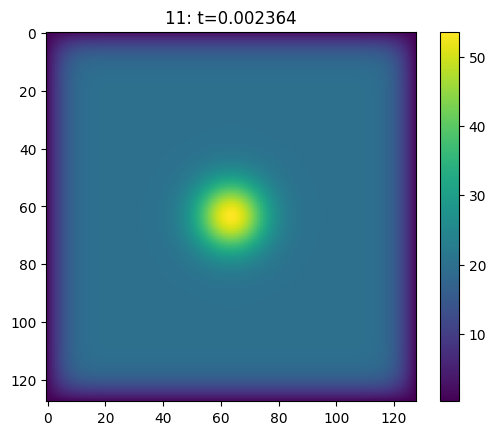

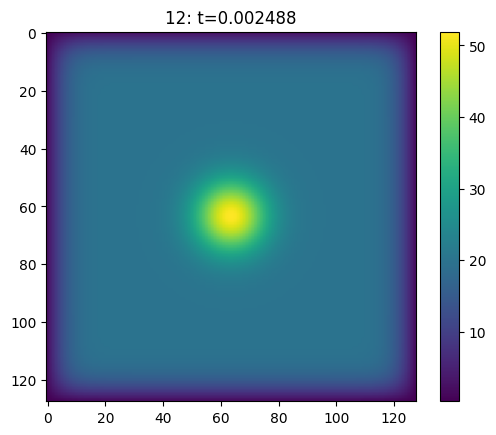

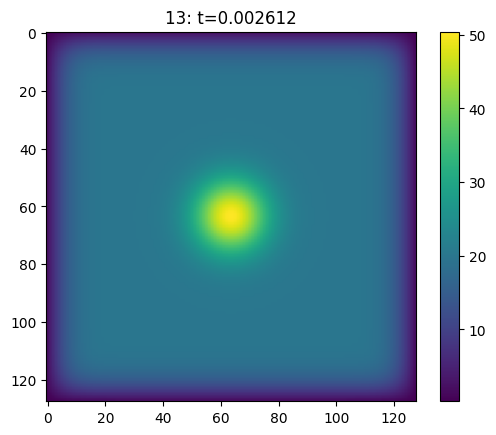

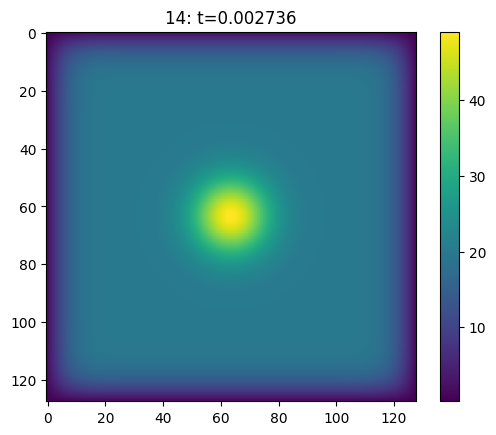

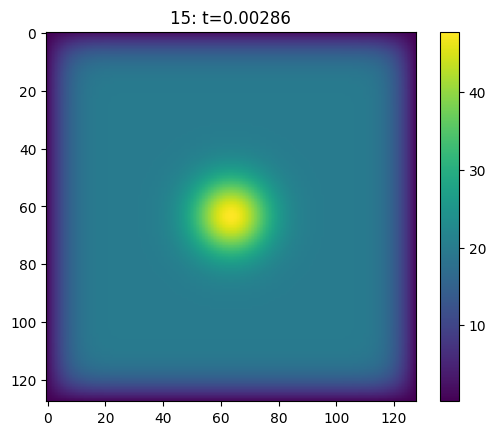

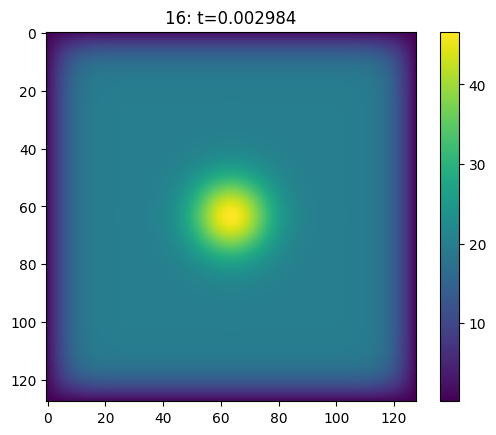

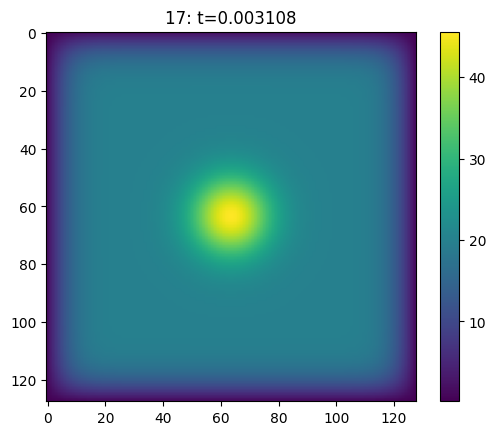

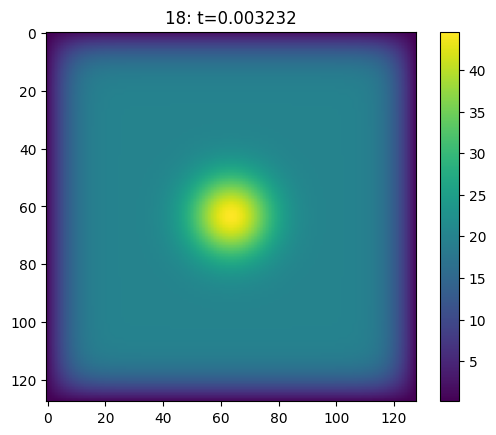

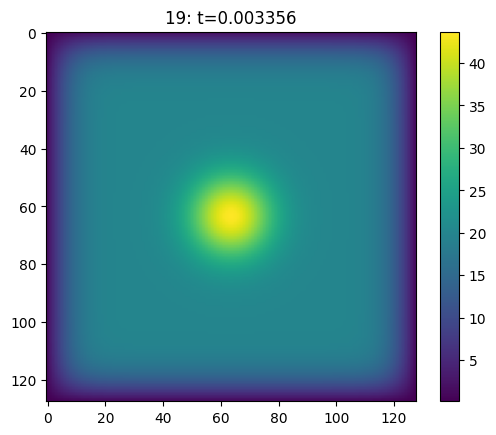

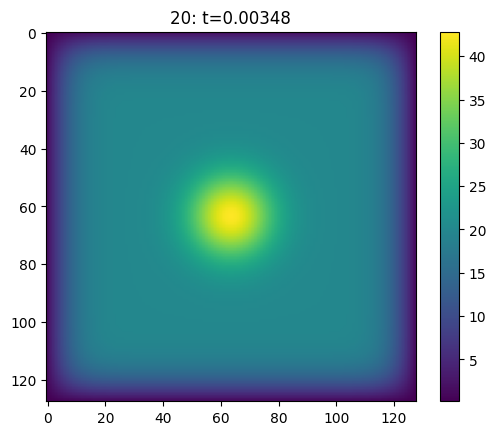

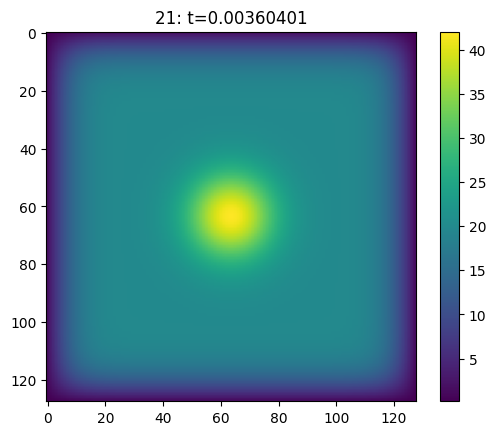

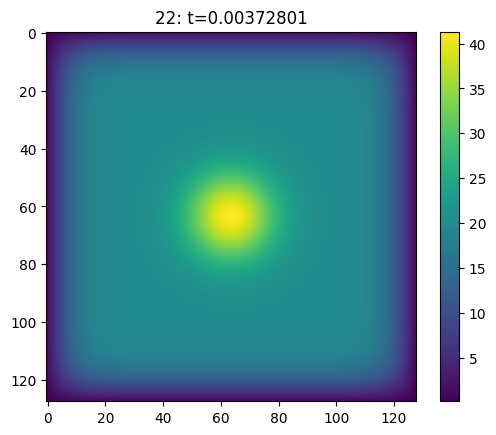

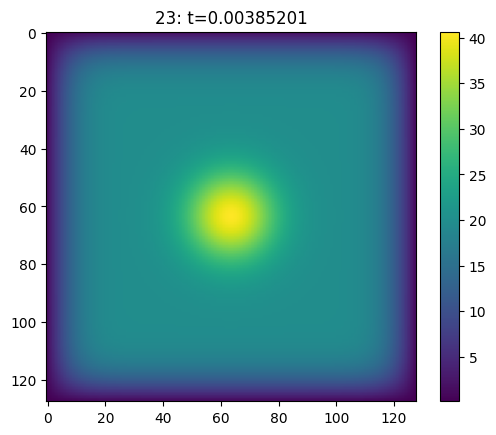

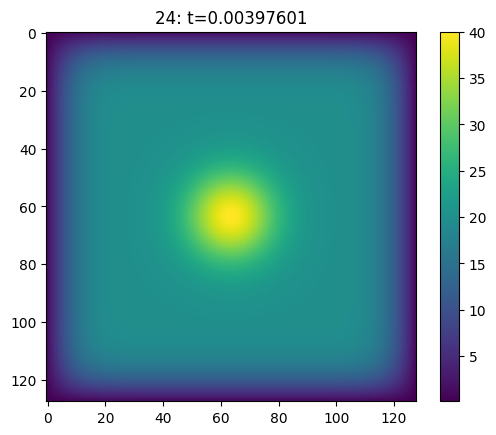

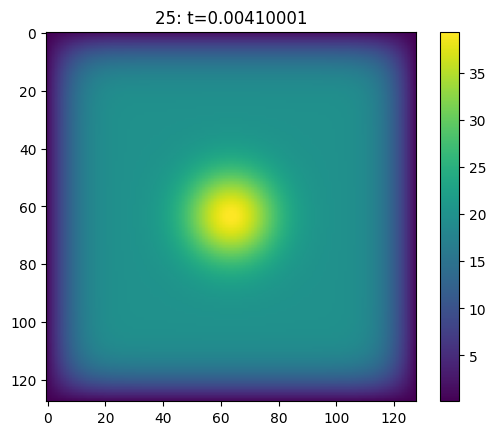

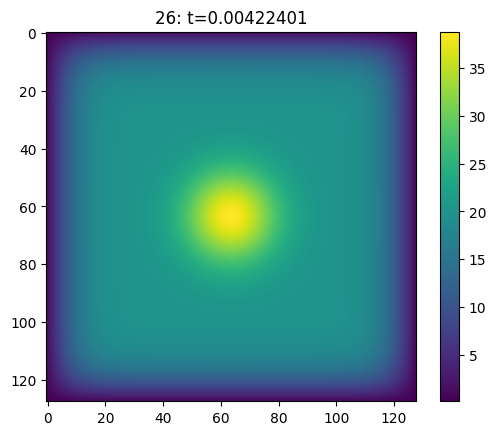

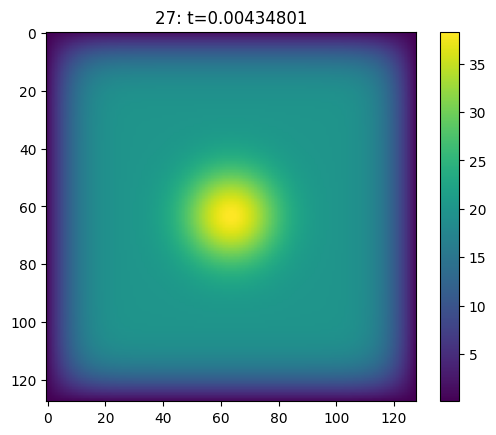

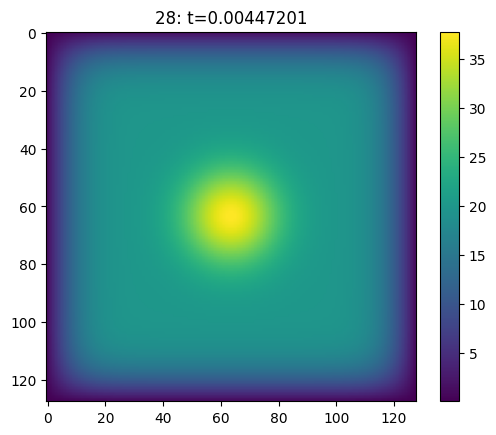

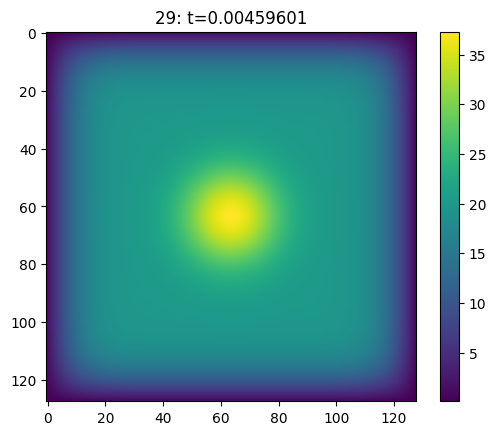

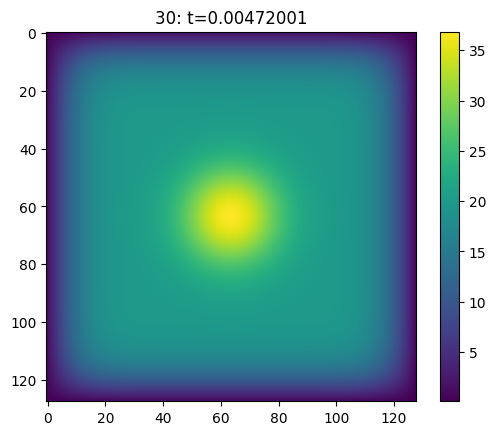

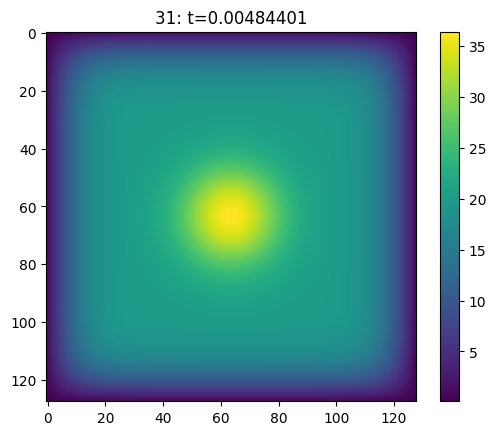

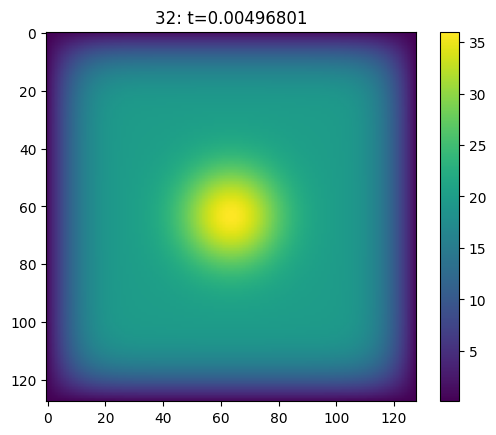

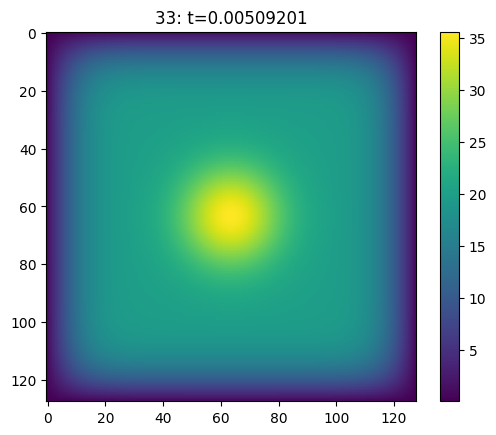

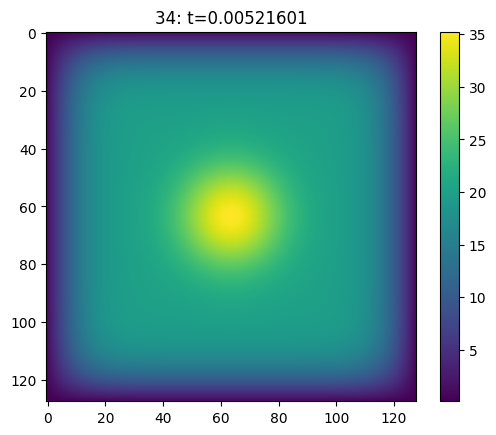

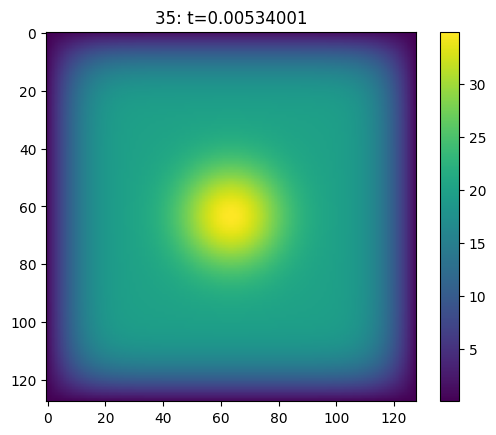

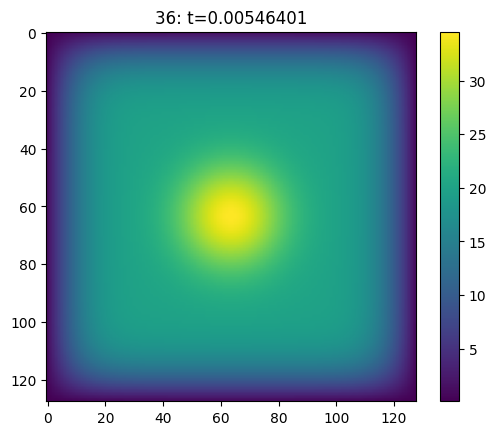

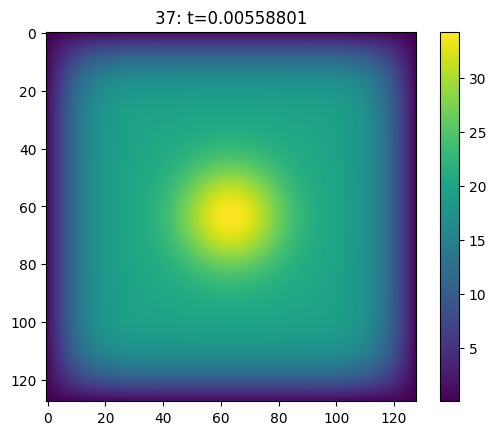

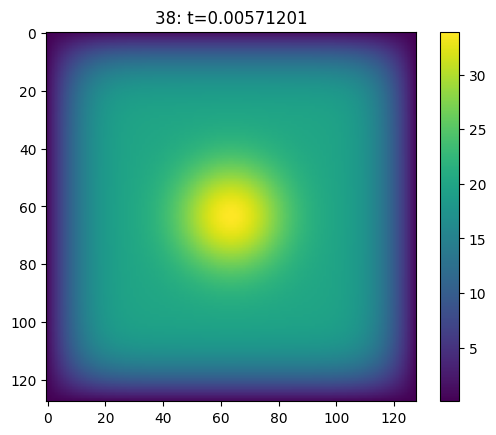

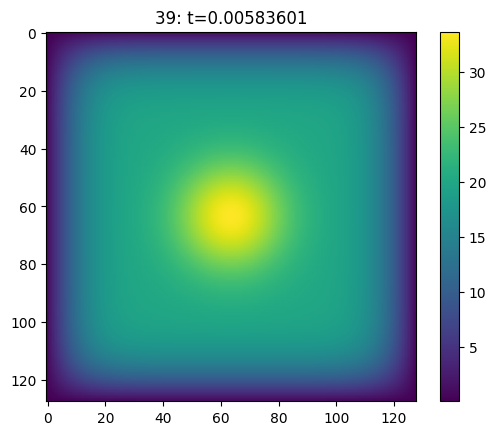

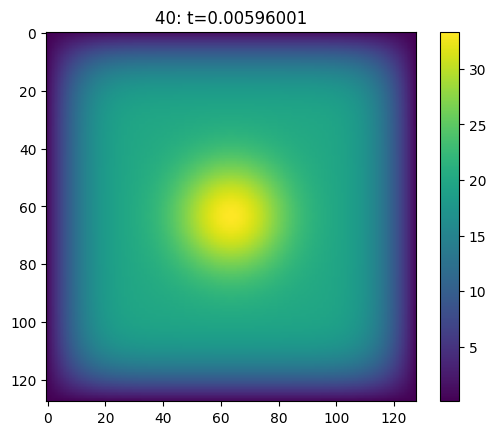

T range =  0.079437604524087 33.34744719195353
delta range =  -0.5973639388709364 0.0003866963344023763


<Figure size 640x480 with 0 Axes>

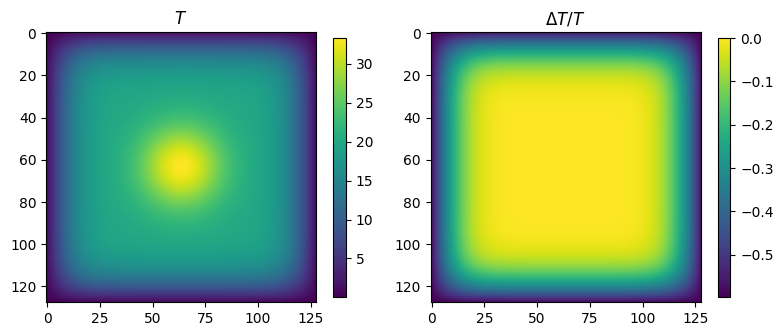

In [14]:
# set up the grid and initial condition
n = 128
T = np.zeros((n, n))
x = np.linspace(0, 1, n)
dx = x[1] - x[0]
xx, yy = np.meshgrid(x, x)
x0 = (0.5, 0.5)  # location of the gaussian
t0 = 0.001  # initial time
T = gaussian(xx, yy, x0, t0)

# timesteps
alpha = 2
nsteps = 40
dt = alpha * dx**2
AL, AR = construct_matrices(n, alpha)

%matplotlib
plt.imshow(T)
plt.title("%d: t=%lg" % (0, t0))
plt.colorbar()
plt.show()

Tnew = np.zeros_like(T)
B = np.zeros_like(T)

# We take twice as many steps here because we are doing half-timesteps
for i in range(2 * nsteps):
    # Compute the right-hand side matrix row by row
    for j in range(n):
        B[j, :] = AR @ T[j, :]

    # and now solve column by column for the new T
    for j in range(n):
        Tnew[:, j] = scipy.linalg.solve_banded((1, 1), AL, B[:, j])

    # take the transpose to swap directions for the next half-step
    T = Tnew.T

    if i % 2 == 1:
        ti = t0 + dt * (1 + i // 2)
        plt.clf()
        plt.imshow(T)
        plt.title("%d: t=%lg" % (1 + i // 2, ti))
        plt.colorbar()
        plt.show()
        plt.pause(1e-3)

# compare the result with the analytic one
ti = t0 + dt * (1 + i // 2)
delta = (T - gaussian(xx, yy, x0, ti)) / np.max(T)
print("T range = ", np.min(T), np.max(T))
print("delta range = ", np.min(delta), np.max(delta))

%matplotlib inline
plt.clf()
fig = plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(T)
plt.title(r"$T$")
plt.colorbar(shrink=0.7)
plt.subplot(122)
plt.imshow(delta)
plt.title(r"$\Delta T/T$")
plt.colorbar(shrink=0.7)
plt.tight_layout()
plt.show()

ADI step 1/200
ADI step 21/200
ADI step 41/200
ADI step 61/200
ADI step 81/200
ADI step 101/200
ADI step 121/200
ADI step 141/200
ADI step 161/200
ADI step 181/200


/var/folders/dv/xz6pnrys46vft3nm92fd_m9m0000gn/T/ipykernel_80700/428106354.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


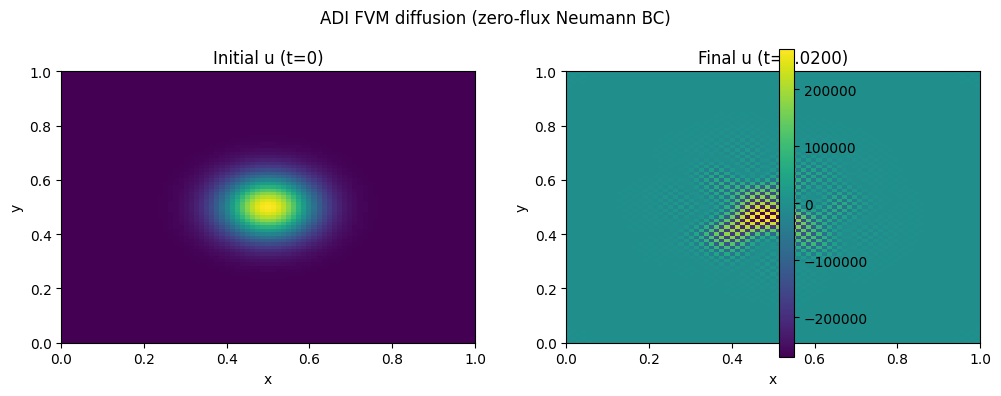

In [20]:
"""
ADI solver for 2D diffusion with zero-flux (Neumann) BCs.

PDE: u_t = D * (u_xx + u_yy)
Domain: rectangular uniform grid
BC: zero normal flux on all boundaries (Neumann)
Method: Peaceman-Rachford ADI:
    (I - r_x A_x) u*     = (I + r_y A_y) u^n
    (I - r_y A_y) u^{n+1}= (I + r_x A_x) u*
where r_x = D*dt/(2*dx^2), r_y = D*dt/(2*dy^2)
A_x and A_y are discrete 1D second-derivative operators implementing Neumann BCs.
"""

import numpy as np
import matplotlib.pyplot as plt


def thomas_solve(a, b, c, d):
    """
    Solve tridiagonal system(s) with Thomas algorithm:
      a[i]*x[i-1] + b[i]*x[i] + c[i]*x[i+1] = d[i]
    a, b, c are 1D arrays of length N. Convention: a[0] is unused (0), c[-1] is unused (0).
    d can be shape (N,) or (N, M) for M RHS columns. Returns x with same shape as d.
    Raises ValueError if a pivot is (near) zero.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    c = np.asarray(c, dtype=float)
    d = np.asarray(d, dtype=float)
    N = len(b)
    if d.ndim == 1:
        d = d.reshape(N, 1)
    _, M = d.shape

    # Copy to avoid modifying input
    cp = np.zeros(N, dtype=float)
    dp = np.zeros((N, M), dtype=float)

    tiny = 1e-14
    # first row
    if abs(b[0]) < tiny:
        raise ValueError("Zero pivot on first diagonal element in Thomas solver.")
    cp[0] = c[0] / b[0]
    dp[0, :] = d[0, :] / b[0]

    for i in range(1, N):
        denom = b[i] - a[i] * cp[i - 1]
        if abs(denom) < tiny:
            raise ValueError(f"Zero pivot encountered in Thomas solver at row {i}.")
        cp[i] = (c[i] / denom) if i < N - 1 else 0.0
        dp[i, :] = (d[i, :] - a[i] * dp[i - 1, :]) / denom

    # back substitution
    x = np.zeros_like(dp)
    x[-1, :] = dp[-1, :]
    for i in range(N - 2, -1, -1):
        x[i, :] = dp[i, :] - cp[i] * x[i + 1, :]

    return x if x.shape[1] > 1 else x[:, 0]


def build_1d_neumann_tridiag(N):
    """
    Build 1D tridiagonal coefficients (a, b, c) for the discrete second derivative operator A
    with zero-flux (Neumann) BCs on N grid points. The operator is intended to be used as:
        (A @ u)_i = a[i]*u_{i-1} + b[i]*u_i + c[i]*u_{i+1}
    WITHOUT dividing by dx^2. (Caller includes the dx^2 factor into r.)
    Scheme used (ghost-cell mirror / central-difference consistent):
      interior:   a=-1, b= 2, c=-1   (standard second-difference)
      left bc i=0:  b= 2, c=-2        (u_x = 0 -> mirror -> u_{-1}=u_1)
      right bc i=N-1: a=-2, b=2
    """
    if N <= 0:
        raise ValueError("N must be positive")
    a = np.zeros(N, dtype=float)
    b = np.zeros(N, dtype=float)
    c = np.zeros(N, dtype=float)

    if N == 1:
        b[0] = 0.0
        return a, b, c

    # interior
    for i in range(1, N - 1):
        a[i] = -1.0
        b[i] = 2.0
        c[i] = -1.0
    # left boundary
    b[0] = 2.0
    c[0] = -2.0
    # right boundary
    a[-1] = -2.0
    b[-1] = 2.0

    return a, b, c


def apply_tridiag(a, b, c, uline):
    """
    Compute (A @ uline) where A is given by tridiag a,b,c (same format as build_1d...).
    uline is 1D array length N. Returns 1D array length N.
    """
    N = len(uline)
    res = np.zeros_like(uline, dtype=float)
    if N == 1:
        return res  # zero
    # interior
    for i in range(1, N - 1):
        res[i] = a[i] * uline[i - 1] + b[i] * uline[i] + c[i] * uline[i + 1]
    # boundaries
    res[0] = b[0] * uline[0] + c[0] * uline[1]
    res[-1] = a[-1] * uline[-2] + b[-1] * uline[-1]
    return res


def adi_diffusion(u0, D, dx, dy, dt, n_steps, verbose=False):
    """
    ADI solver for u_t = D*(u_xx + u_yy).
    Inputs:
      u0 : 2D numpy array shape (Nx, Ny) initial condition
      D  : diffusion coefficient
      dx, dy : grid spacing
      dt : time step
      n_steps : number of ADI time steps to perform
      verbose : if True, prints progress
    Returns:
      u (2D array) at final time
    Notes:
      - ADI used here is unconditionally stable for the diffusion equation.
      - r_x = D*dt/(2*dx^2), r_y = D*dt/(2*dy^2)
      - Implements Neumann (zero normal flux) BC via the tridiag operators defined above.
    """
    u = u0.astype(float).copy()
    Nx, Ny = u.shape
    rx = D * dt / (2.0 * dx * dx)
    ry = D * dt / (2.0 * dy * dy)

    # Build 1D tridiagonals for x and y derivative operators (A_x, A_y)
    ax, bx, cx = build_1d_neumann_tridiag(Nx)
    ay, by, cy = build_1d_neumann_tridiag(Ny)

    # Precompute tridiagonal coefficients for the linear systems we will solve:
    # For solve in x: (I - rx * A_x)  <-- coefficients a_x_sys, b_x_sys, c_x_sys
    a_x_sys = -rx * ax
    b_x_sys = 1.0 - rx * bx
    c_x_sys = -rx * cx

    # For solve in y: (I - ry * A_y)
    a_y_sys = -ry * ay
    b_y_sys = 1.0 - ry * by
    c_y_sys = -ry * cy

    # For the RHS multiplications we need (I + r * A)
    # but we will compute those via apply_tridiag (no full matrix assembly)
    # (I + ry*A_y) and (I + rx*A_x) are not solved directly, they are used to build RHS.

    for step in range(n_steps):
        if verbose and (step % max(1, n_steps // 10) == 0):
            print(f"ADI step {step + 1}/{n_steps}")

        # First half-step:
        # RHS = (I + ry*A_y) u^n  (for each x-line)
        RHS = np.empty_like(u)
        for i in range(Nx):
            Ay_u = apply_tridiag(ay, by, cy, u[i, :])
            RHS[i, :] = u[i, :] + ry * Ay_u

        # Solve (I - rx * A_x) u* = RHS  along x for each column j
        u_star = np.empty_like(u)
        for j in range(Ny):
            u_star[:, j] = thomas_solve(a_x_sys, b_x_sys, c_x_sys, RHS[:, j])

        # Second half-step:
        # RHS2 = (I + rx*A_x) u*   (for each y-column)
        RHS2 = np.empty_like(u)
        for j in range(Ny):
            Ax_u = apply_tridiag(ax, bx, cx, u_star[:, j])
            RHS2[:, j] = u_star[:, j] + rx * Ax_u

        # Solve (I - ry * A_y) u^{n+1} = RHS2  along y for each row i
        u_new = np.empty_like(u)
        for i in range(Nx):
            u_new[i, :] = thomas_solve(a_y_sys, b_y_sys, c_y_sys, RHS2[i, :])

        u = u_new

    return u


# -----------------------
# Small usage example
# -----------------------
if __name__ == "__main__":
    # Domain and grid
    Nx, Ny = 81, 81
    Lx, Ly = 1.0, 1.0
    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y, indexing="ij")

    # Physical parameters
    D = 0.05  # diffusion coefficient
    dt = 0.0001  # time step (ADI is unconditionally stable, but choose reasonable dt for accuracy)
    n_steps = 200  # number of ADI steps -> final time = dt * n_steps

    # Initial condition: Gaussian bump in center
    sigma = 0.08
    u0 = np.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / (2.0 * sigma**2))

    # Run ADI solver
    u_final = adi_diffusion(u0, D, dx, dy, dt, n_steps, verbose=True)

    # Plot initial and final state
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(u0.T, origin="lower", extent=(0, Lx, 0, Ly), aspect="auto")
    axes[0].set_title("Initial u (t=0)")
    im1 = axes[1].imshow(
        u_final.T, origin="lower", extent=(0, Lx, 0, Ly), aspect="auto"
    )
    axes[1].set_title(f"Final u (t={dt * n_steps:.4f})")
    for ax in axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")
    fig.colorbar(im1, ax=axes.ravel().tolist())
    plt.suptitle("ADI FVM diffusion (zero-flux Neumann BC)")
    plt.tight_layout()
    plt.show()